# Data Visualization
This notebook describes how the finalized visualization was generated to address the question of interest: 

**Which US counties emit the most CO₂ from non-residential fuel use per square meter of building floor area?**

In [25]:
#%pip install duckdb
#%pip install pandas 
import duckdb as duckdb 
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
# Establish connection 
# Established connection to database
conn = duckdb.connect("/Users/vedikashirtekar/MEDS/EDS-213/eds-213-labs/my-db.duckdb")

In [17]:
# We are going to execute the SQL developed here using .sql 
sources_emissions = conn.sql("""SELECT s.source_name, s.iso3_country, SUM(e.emissions_quantity), s.capacity, ROUND(SUM(e.emissions_quantity) / (s.capacity), 4) AS co2_per_m2 
                             FROM sources s JOIN emission_records e ON s.source_id = e.source_id 
                             WHERE e.sector LIKE 'buildings' 
                             GROUP BY s.source_name, s.iso3_country, s.capacity 
                             ORDER BY co2_per_m2 DESC""").df()

In [19]:
# We can now drop the NANs... 
sources_emissions_clean = sources_emissions.dropna()
#sources_emissions

In [23]:
sources_top_10 = sources_emissions_clean.head(10)
sources_top_10.head()

,source_name,iso3_country,sum(e.emissions_quantity),capacity,co2_per_m2
5,Wade Hampton Census Area,USA,15790.26319,3371.450,4.6835
6,Nome Census Area,USA,23453.06574,5145.689,4.5578
7,Kodiak Island Borough,USA,31083.69212,9427.166,3.2972
8,Northwest Arctic Borough,USA,1218.10237,432.878,2.8140
9,Matanuska-Susitna Borough,USA,351916.72575,126190.342,2.7888


[Text(0.5, 1.0, 'CO${_2}$ Emissions per m${^2}$')]

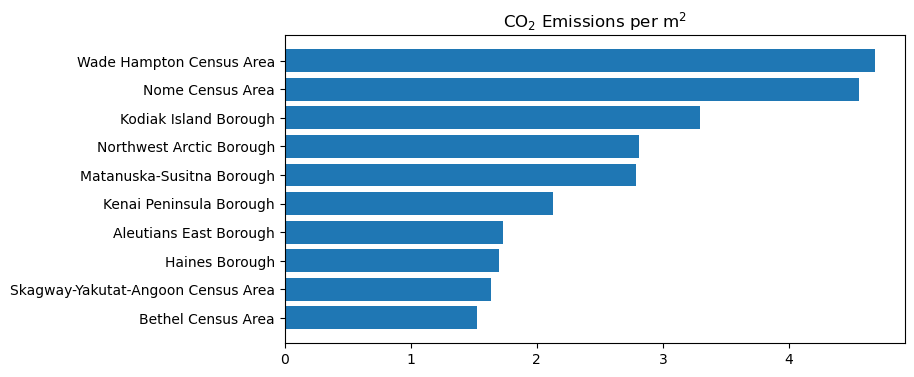

In [ ]:
# We can create a ranked bar chart 
fig, ax = plt.subplots(figsize = (8,4))
source_name = sources_top_10["source_name"]
co2_per_m2 = sources_top_10["co2_per_m2"]
ax.barh(source_name, co2_per_m2)
ax.invert_yaxis() # Read the sources top to bottom
ax.set(title = "CO${_2}$ Emissions per m${^2}$ Per Non-Residential S")

In [ ]:
conn.close() #To ensure lock isn't there